In [1]:
# Get the number of data for each classes
import h5py
import scipy.io as sio
import numpy as np
import os
from tqdm import tqdm
from collections import Counter

# ============================================================================
# CONFIGURATION
# ============================================================================
DATA_DIR = '/Users/ha/Documents/Final Year project/brainTumorDataPublic'

CLASS_NAMES = {
    1: 'Meningioma',
    2: 'Glioma',
    3: 'Pituitary',
    4: 'Normal',
    0: 'Normal (label 0)',
}

# ============================================================================
# SCAN
# ============================================================================
mat_files = sorted(
    [f for f in os.listdir(DATA_DIR) if f.endswith('.mat')],
    key=lambda f: int(''.join(filter(str.isdigit, f)))
                  if any(c.isdigit() for c in f) else 0
)

print(f"\n📂 Folder   : {DATA_DIR}")
print(f"📁 Total .mat files found: {len(mat_files)}\n")

counts      = Counter()
errors      = 0
unknown     = []

for filename in tqdm(mat_files, desc="Scanning"):
    path = os.path.join(DATA_DIR, filename)
    try:
        label = None

        # Try HDF5 first (original Figshare v7.3)
        try:
            with h5py.File(path, 'r') as f:
                label = int(np.array(f['cjdata']['label']).flat[0])
        except (OSError, KeyError):
            # Fall back to scipy (v5)
            mat = sio.loadmat(path)
            label = int(mat['cjdata'][0, 0]['label'][0][0])

        counts[label] += 1

    except Exception as e:
        errors += 1

# ============================================================================
# REPORT
# ============================================================================
print(f"\n{'='*45}")
print(f"  DATASET CLASS DISTRIBUTION")
print(f"{'='*45}")

total = sum(counts.values())
for label in sorted(counts.keys()):
    name  = CLASS_NAMES.get(label, f"Unknown (label {label})")
    count = counts[label]
    pct   = count / total * 100 if total > 0 else 0
    bar   = '█' * int(pct / 2)
    print(f"  {name:<22} : {count:>5} images  ({pct:5.1f}%)  {bar}")

print(f"  {'─'*43}")
print(f"  {'Total':<22} : {total:>5} images  (100.0%)")

if errors:
    print(f"\n  ⚠️  Failed to read: {errors} files")

print(f"{'='*45}\n")


📂 Folder   : /Users/ha/Documents/Final Year project/brainTumorDataPublic
📁 Total .mat files found: 9860



Scanning: 100%|███████████████████████████| 9860/9860 [00:06<00:00, 1500.16it/s]


  DATASET CLASS DISTRIBUTION
  Meningioma             :   708 images  (  7.2%)  ███
  Glioma                 :  1426 images  ( 14.5%)  ███████
  Pituitary              :   930 images  (  9.4%)  ████
  Normal                 :  6796 images  ( 68.9%)  ██████████████████████████████████
  ───────────────────────────────────────────
  Total                  :  9860 images  (100.0%)



In [5]:
# Under sampling the data 
import h5py
import scipy.io as sio
import numpy as np
import os
import shutil
from tqdm import tqdm
from collections import defaultdict

# ============================================================================
# CONFIGURATION
# ============================================================================
DATA_DIR   = '/Users/ha/Documents/Final Year project/brainTumorDataPublic'
OUTPUT_DIR = '/Users/ha/Documents/Final Year project/brainTumorDataPublic_balanced'

SAMPLES_PER_CLASS = 708   # = smallest class (Meningioma)

CLASS_NAMES = {
    1: 'Meningioma',
    2: 'Glioma',
    3: 'Pituitary',
    4: 'Normal',
    0: 'Normal',
}

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================================
# STEP 1 — SCAN ALL FILES AND GROUP BY CLASS
# ============================================================================
print(f"\n📂 Scanning {DATA_DIR}...")

mat_files = sorted(
    [f for f in os.listdir(DATA_DIR) if f.endswith('.mat')],
    key=lambda f: int(''.join(filter(str.isdigit, f)))
                  if any(c.isdigit() for c in f) else 0
)

grouped = defaultdict(list)   # {label: [filename, ...]}
errors  = 0

for filename in tqdm(mat_files, desc="Grouping by class"):
    path = os.path.join(DATA_DIR, filename)
    try:
        label = None
        try:
            with h5py.File(path, 'r') as f:
                label = int(np.array(f['cjdata']['label']).flat[0])
        except (OSError, KeyError):
            mat   = sio.loadmat(path)
            label = int(mat['cjdata'][0, 0]['label'][0][0])

        grouped[label].append(filename)

    except Exception:
        errors += 1

print(f"\n  Found per class before balancing:")
for label, files in sorted(grouped.items()):
    print(f"    {CLASS_NAMES.get(label, f'Label {label}'):<15} : {len(files)} files")

# ============================================================================
# STEP 2 — SELECT 708 FROM EACH CLASS
# ============================================================================
print(f"\n📦 Selecting {SAMPLES_PER_CLASS} images per class...")

selected_files = []   # list of (src_path, label) in class order

for label, files in sorted(grouped.items()):
    chosen = files[:SAMPLES_PER_CLASS]
    for filename in chosen:
        selected_files.append((os.path.join(DATA_DIR, filename), label))

# ============================================================================
# STEP 3 — COPY AND RENAME SEQUENTIALLY 1.mat → 2832.mat
# No more jumping numbers — clean sequential naming so augmentation
# can later produce clean blocks (1→2832 originals, 2833→5664 aug round 1...)
# The label stays embedded inside the .mat file so training still reads it
# correctly — only the filename changes.
# ============================================================================
print(f"\n✏️  Renaming sequentially 1.mat → {len(selected_files)}.mat...")
print(f"   Output → {OUTPUT_DIR}\n")

summary      = defaultdict(int)
total_copied = 0

for new_index, (src_path, label) in enumerate(
        tqdm(selected_files, desc="Copying & renaming"), start=1):

    new_filename = f"{new_index}.mat"
    dst_path     = os.path.join(OUTPUT_DIR, new_filename)
    shutil.copy2(src_path, dst_path)

    class_name = CLASS_NAMES.get(label, f'Label_{label}')
    summary[class_name] += 1
    total_copied         += 1

# ============================================================================
# REPORT
# ============================================================================
print(f"\n{'='*55}")
print(f"  BALANCED DATASET — SEQUENTIAL RENAMING COMPLETE")
print(f"{'='*55}")
for class_name, count in summary.items():
    print(f"  {class_name:<15} : {count} images")
print(f"  {'─'*51}")
print(f"  {'Total':<15} : {total_copied} images  (1.mat → {total_copied}.mat)")
print(f"\n  Output folder : {OUTPUT_DIR}")
print(f"  Naming        : Clean sequential — no jumping numbers ✅")
print(f"  Labels        : Preserved inside each .mat file ✅")

if errors:
    print(f"\n  ⚠️  {errors} files could not be read and were skipped")

print(f"{'='*55}\n")
print(f"✅ Done! Update DATA_DIR in your training scripts to:")
print(f"   {OUTPUT_DIR}\n")
print(f"💡 After augmentation the layout will be:")
print(f"   Originals  : 1.mat    → {total_copied}.mat")
print(f"   Aug round 1: {total_copied+1}.mat  → {total_copied*2}.mat")
print(f"   Aug round 2: {total_copied*2+1}.mat  → {total_copied*3}.mat")
print(f"   ... and so on — clean sequential blocks ✅")


📂 Scanning /Users/ha/Documents/Final Year project/brainTumorDataPublic...


Grouping by class: 100%|██████████████████| 9860/9860 [00:07<00:00, 1400.19it/s]



  Found per class before balancing:
    Meningioma      : 708 files
    Glioma          : 1426 files
    Pituitary       : 930 files
    Normal          : 6796 files

📦 Selecting 708 images per class...

✏️  Renaming sequentially 1.mat → 2832.mat...
   Output → /Users/ha/Documents/Final Year project/brainTumorDataPublic_balanced



Copying & renaming: 100%|█████████████████| 2832/2832 [00:02<00:00, 1074.79it/s]


  BALANCED DATASET — SEQUENTIAL RENAMING COMPLETE
  Meningioma      : 708 images
  Glioma          : 708 images
  Pituitary       : 708 images
  Normal          : 708 images
  ───────────────────────────────────────────────────
  Total           : 2832 images  (1.mat → 2832.mat)

  Output folder : /Users/ha/Documents/Final Year project/brainTumorDataPublic_balanced
  Naming        : Clean sequential — no jumping numbers ✅
  Labels        : Preserved inside each .mat file ✅

✅ Done! Update DATA_DIR in your training scripts to:
   /Users/ha/Documents/Final Year project/brainTumorDataPublic_balanced

💡 After augmentation the layout will be:
   Originals  : 1.mat    → 2832.mat
   Aug round 1: 2833.mat  → 5664.mat
   Aug round 2: 5665.mat  → 8496.mat
   ... and so on — clean sequential blocks ✅


In [6]:
# Augementation of the the data
import os
import h5py
import numpy as np
import scipy.io as sio
from scipy.ndimage import zoom  # New import for zooming
from tqdm import tqdm

# ============================================================================
# 1. CONFIGURATION & PATHS
# ============================================================================
input_folder = '/Users/ha/Documents/Final Year project/brainTumorDataPublic_balanced'
output_folder = '/Users/ha/Documents/Final Year project/Dataset/brainTumorDataPublic/'
os.makedirs(output_folder, exist_ok=True)

# --- AUGMENTATION FUNCTIONS ---
def rotate_image(img, angle):
    """Rotate image by 0, 90, 180, or 270 degrees."""
    return np.rot90(img, k=angle//90)

def zoom_image(img, zoom_factor):
    """Zoom in (>1) or out (<1) while maintaining original dimensions."""
    h, w = img.shape
    
    # Perform the zoom
    # order=1 is bilinear interpolation (good balance of speed/quality)
    zoomed = zoom(img, zoom_factor, order=1)
    zh, zw = zoomed.shape

    if zoom_factor > 1:
        # Zoom In: Crop the center
        top = (zh - h) // 2
        left = (zw - w) // 2
        return zoomed[top:top+h, left:left+w]
    else:
        # Zoom Out: Pad with zeros
        pad_h = (h - zh) // 2
        pad_w = (w - zw) // 2
        result = np.zeros((h, w), dtype=img.dtype)
        result[pad_h:pad_h+zh, pad_w:pad_w+zw] = zoomed
        return result

# --- SMART LOADER FUNCTION ---
def load_mat_any_version(path):
    """Handles both v7 and v7.3 files."""
    try:
        mat_data = sio.loadmat(path)
        raw = mat_data['cjdata'][0, 0]
        pid_val = raw['PID']
        pid_str = str(pid_val[0]) if pid_val.size > 0 else "Unknown"
        return {
            'image': raw['image'].astype(np.float32),
            'label': float(raw['label'][0, 0]),
            'PID': pid_str,
            'tumorMask': raw['tumorMask'],
            'tumorBorder': raw['tumorBorder']
        }
    except (NotImplementedError, ValueError):
        with h5py.File(path, 'r') as f:
            cj = f['cjdata']
            try:
                pid_array = np.array(cj['PID'])
                pid_str = str(pid_array) if pid_array.ndim == 0 else "".join([chr(c[0]) for c in pid_array])
            except:
                pid_str = "Unknown"
            return {
                'image': np.array(cj['image']).T.astype(np.float32),
                'label': float(np.array(cj['label'])[0,0]),
                'PID': pid_str,
                'tumorMask': np.array(cj['tumorMask']).T,
                'tumorBorder': np.array(cj['tumorBorder']).T
            }

# ============================================================================
# 2. MAIN EXECUTION LOOP
# ============================================================================
file_list = sorted([f for f in os.listdir(input_folder) if f.endswith('.mat')])
num_files = len(file_list)

print(f"🚀 Found {num_files} files. Generating 6 variants per file (4 Rotations + 2 Zooms)...")
print(f"📦 Total expected files: {num_files * 6}")

for idx, filename in enumerate(tqdm(file_list)):
    mat_path = os.path.join(input_folder, filename)
    
    try:
        data_dict = load_mat_any_version(mat_path)
        img = data_dict['image']
        
        # Define our 6 variants
        # format: (type, parameter)
        variants = [
            ('rot', 0), ('rot', 90), ('rot', 180), ('rot', 270), 
            ('zoom', 1.15), # Zoom In 15%
            ('zoom', 0.85)  # Zoom Out 15%
        ]
        
        for v_idx, (v_type, param) in enumerate(variants):
            # 1. Apply Augmentation
            if v_type == 'rot':
                processed_img = rotate_image(img, param)
            else:
                processed_img = zoom_image(img, param)
            
            # 2. Create the new structure
            new_dict = data_dict.copy()
            new_dict['image'] = processed_img
            
            # 3. Calculate unique index
            # v_idx 0-3: Rotations
            # v_idx 4: Zoom In
            # v_idx 5: Zoom Out
            new_idx = (v_idx * num_files) + (idx + 1)
            
            # 4. Save
            sio.savemat(os.path.join(output_folder, f"{new_idx}.mat"), {'cjdata': new_dict})

    except Exception as e:
        print(f"⚠️ Error on {filename}: {e}")

print(f"\n✅ Done! Dataset expanded to 6x augmentation: {output_folder}")

🚀 Found 2832 files. Generating 6 variants per file (4 Rotations + 2 Zooms)...
📦 Total expected files: 16992


100%|███████████████████████████████████████| 2832/2832 [01:02<00:00, 45.27it/s]


✅ Done! Dataset expanded to 6x augmentation: /Users/ha/Documents/Final Year project/Dataset/brainTumorDataPublic/



  Dynamic Per-Image Preprocessing
  Formula: T_opt = 0.75μ + 0.25σ  (applied per image)
  Gaussian σ = 1
  Total files: 16992



Preprocessing: 100%|█████████████████████| 16992/16992 [02:21<00:00, 119.85it/s]
/var/folders/mg/8lc7zk594_51ks8zd9b9h72r0000gn/T/ipykernel_29993/869591898.py:260: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot(class_data, labels=class_labels, patch_artist=True)



  PREPROCESSING COMPLETE
  Successfully processed : 16992/16992
  Skipped (no tissue)    : 0
  Failed                 : 0
  Total time             : 141.78s
  Output directory       : /Users/ha/Documents/Final Year project/Dataset/brainTumorDataPublic/preprocessed_dynamic_per_image/

  📊 Per-Image Threshold Statistics
  ────────────────────────────────────────
  Min threshold   : 30.77
  Max threshold   : 1760.05
  Mean threshold  : 497.71
  Std of thresholds: 278.30

  ⚠️  Range of 1729.28
  proves that a single global value would be wrong for many images.


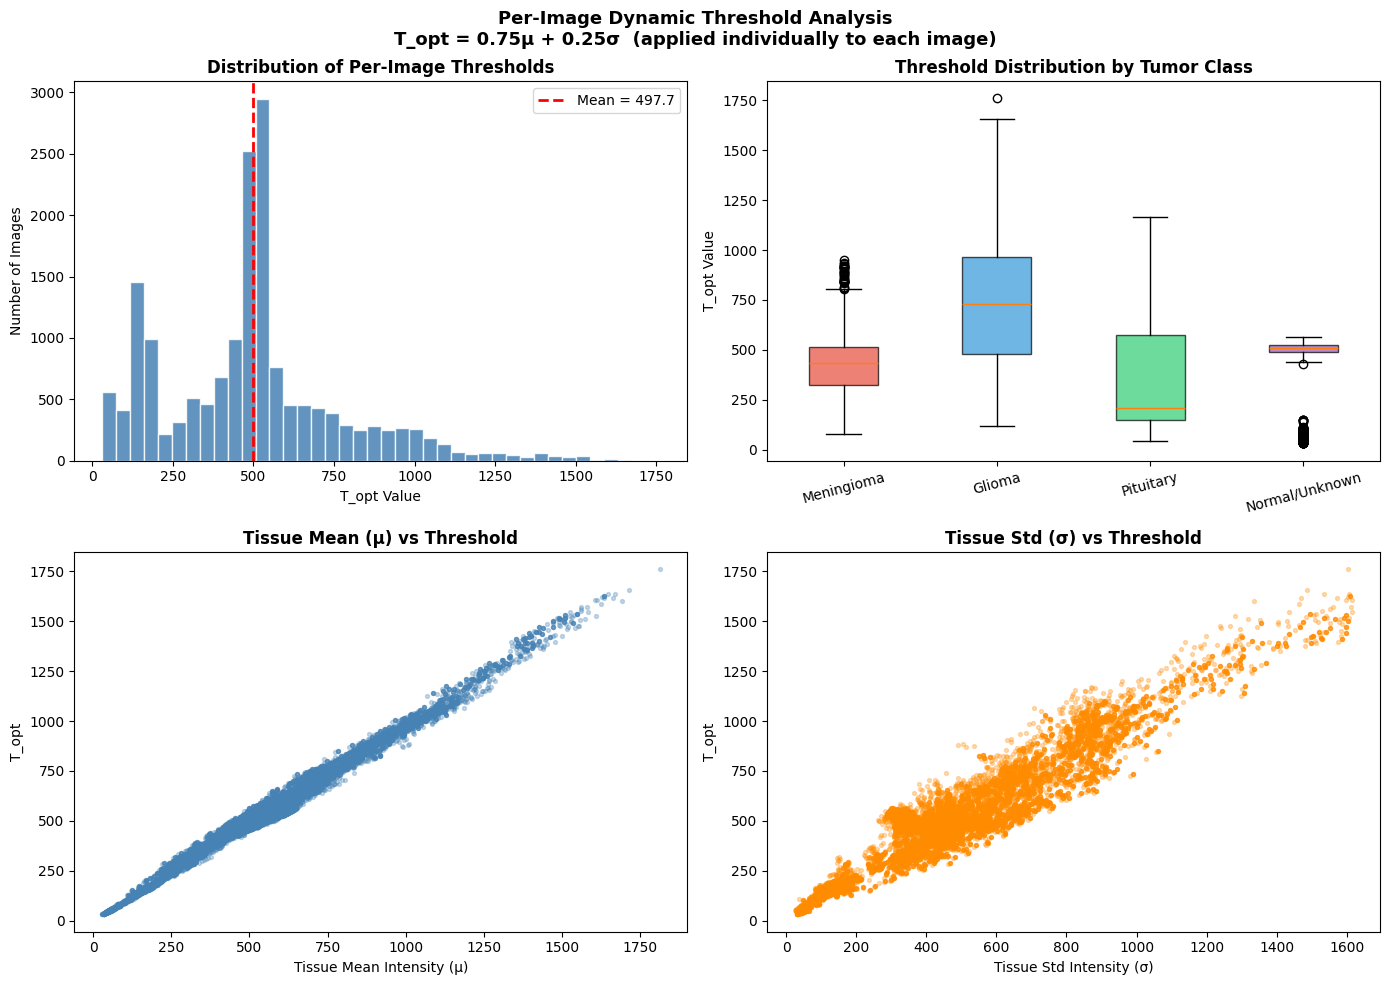


  📊 Analysis plot saved → preprocessing_analysis_dynamic/dynamic_threshold_analysis.png
  💾 Per-image threshold log saved → preprocessing_analysis_dynamic/per_image_thresholds.csv

  📋 Per-Class Threshold Summary
  ───────────────────────────────────────────────────────
                Mean T_opt     Std     Min      Max  Count
class                                                     
Glioma              741.54  324.28  120.11  1760.05   4248
Meningioma          423.00  153.29   80.43   950.35   4248
Normal/Unknown      449.52  157.53   30.77   564.39   4248
Pituitary           376.76  272.75   43.35  1166.85   4248
  ───────────────────────────────────────────────────────

  ✅ Done — every image was preprocessed with its own T_opt value.
  Output saved to: /Users/ha/Documents/Final Year project/Dataset/brainTumorDataPublic/preprocessed_dynamic_per_image/



In [7]:
# Preprocessed the data
import os
import h5py
import numpy as np
import scipy.io as sio
from scipy.ndimage import gaussian_filter
from scipy.io import loadmat
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import time
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

# ============================================================================
# CONFIGURATION
# ============================================================================
INPUT_FOLDER   = '/Users/ha/Documents/Final Year project/Dataset/brainTumorDataPublic'
OUTPUT_FOLDER  = '/Users/ha/Documents/Final Year project/Dataset/brainTumorDataPublic/preprocessed_dynamic_per_image/'
ANALYSIS_DIR   = 'preprocessing_analysis_dynamic'

GAUSSIAN_SIGMA = 1       # same as before
MEAN_WEIGHT    = 0.75    # your novel formula: T_opt = 0.75μ + 0.25σ
STD_WEIGHT     = 0.25

CLASS_NAMES = {1: 'Meningioma', 2: 'Glioma', 3: 'Pituitary'}

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
os.makedirs(ANALYSIS_DIR,  exist_ok=True)

# ============================================================================
# UNIVERSAL LOADER — handles both HDF5 (v7.3) and Legacy (v5/v7) .mat files
# ============================================================================
def load_any_mat(path):
    """
    Loads a .mat file regardless of format version.
    Strategy A → HDF5  (original Figshare files, v7.3)
    Strategy B → Scipy (augmented and healthy files, v5/v7)
    """
    try:
        # Strategy A: HDF5
        with h5py.File(path, 'r') as f:
            cj = f['cjdata']
            data = {
                'image':       np.array(cj['image']).T,
                'label':       np.array(cj['label']),
                'PID':         np.array(cj['PID']),
                'tumorMask':   np.array(cj['tumorMask']).T,
                'tumorBorder': np.array(cj['tumorBorder']).T
            }
            return data
    except (OSError, KeyError):
        # Strategy B: Scipy
        m  = sio.loadmat(path)
        cj = m['cjdata'][0, 0]
        data = {}
        for name in cj.dtype.names:
            data[name] = cj[name]
        return data


# ============================================================================
# DYNAMIC THRESHOLD CALCULATOR — your novel formula applied per image
# ============================================================================
def calculate_dynamic_threshold(img_smooth):
    """
    Applies T_opt = 0.75 × μ + 0.25 × σ

    Instead of computing μ and σ on ALL pixels (which includes the large
    black background and skews the statistics), we compute them only on
    tissue pixels (intensity > 0) after Gaussian smoothing.

    This ensures the threshold adapts to the actual brain tissue brightness
    of each individual scan — not a one-size-fits-all global value.

    Returns:
        threshold : float — the calculated T_opt for this image
        mean_val  : float — tissue mean (μ)
        std_val   : float — tissue std  (σ)
        has_tissue: bool  — False if image has no non-zero pixels
    """
    tissue_pixels = img_smooth[img_smooth > 0]

    if len(tissue_pixels) == 0:
        return None, None, None, False

    mean_val  = float(np.mean(tissue_pixels))
    std_val   = float(np.std(tissue_pixels))
    threshold = (MEAN_WEIGHT * mean_val) + (STD_WEIGHT * std_val)

    return threshold, mean_val, std_val, True


# ============================================================================
# MAIN PIPELINE
# ============================================================================
mat_files = sorted(
    [f for f in os.listdir(INPUT_FOLDER) if f.endswith('.mat')],
    key=lambda f: int(''.join(filter(str.isdigit, f)))
                  if any(c.isdigit() for c in f) else 0
)

print(f"\n{'='*60}")
print(f"  Dynamic Per-Image Preprocessing")
print(f"  Formula: T_opt = {MEAN_WEIGHT}μ + {STD_WEIGHT}σ  (applied per image)")
print(f"  Gaussian σ = {GAUSSIAN_SIGMA}")
print(f"  Total files: {len(mat_files)}")
print(f"{'='*60}\n")

start_time     = time.time()
success_count  = 0
error_count    = 0
skipped_count  = 0
analysis_rows  = []   # store per-image stats for analysis plots

for filename in tqdm(mat_files, desc="Preprocessing"):
    input_path  = os.path.join(INPUT_FOLDER, filename)
    output_path = os.path.join(OUTPUT_FOLDER, filename)

    try:
        # ── Step 1: Load ──────────────────────────────────────────────────
        data_dict = load_any_mat(input_path)

        # ── Step 2: Extract image ─────────────────────────────────────────
        img = data_dict['image'].astype(np.float32)

        # Get label for analysis logging (not all files have a label field)
        try:
            label_raw = data_dict.get('label', np.array([[0]]))
            if hasattr(label_raw, 'flat'):
                label = int(list(label_raw.flat)[0])
            else:
                label = int(label_raw)
        except Exception:
            label = 0
        class_name = CLASS_NAMES.get(label, 'Normal/Unknown')

        # ── Step 3: Gaussian smoothing ────────────────────────────────────
        img_smooth = gaussian_filter(img, sigma=GAUSSIAN_SIGMA)

        # ── Step 4: Calculate T_opt for THIS specific image ───────────────
        threshold, mean_val, std_val, has_tissue = calculate_dynamic_threshold(img_smooth)

        if not has_tissue:
            # Image has no tissue pixels at all — skip it
            skipped_count += 1
            analysis_rows.append({
                'filename':  filename,
                'label':     label,
                'class':     class_name,
                'mean_val':  None,
                'std_val':   None,
                'threshold': None,
                'status':    'skipped_no_tissue'
            })
            continue

        # ── Step 5: Apply THIS image's own threshold ──────────────────────
        # Every image now gets preprocessed with its own T_opt value
        # instead of a single global average threshold
        img_processed = img_smooth.copy()
        img_processed[img_processed < threshold] = 0

        # ── Step 6: Store processed image back into data dict ─────────────
        data_dict['image'] = img_processed

        # ── Step 7: Save as MATLAB v5 (compatible with training script) ───
        sio.savemat(output_path, {'cjdata': data_dict})

        success_count += 1

        # Log per-image stats for analysis
        removed_pct = (np.sum(img_smooth < threshold) / img_smooth.size) * 100
        analysis_rows.append({
            'filename':   filename,
            'label':      label,
            'class':      class_name,
            'mean_val':   round(mean_val,  2),
            'std_val':    round(std_val,   2),
            'threshold':  round(threshold, 2),
            'removed_pct': round(removed_pct, 2),
            'status':     'success'
        })

    except Exception as e:
        error_count += 1
        analysis_rows.append({
            'filename':  filename,
            'label':     0,
            'class':     'error',
            'mean_val':  None,
            'std_val':   None,
            'threshold': None,
            'status':    f'error: {str(e)}'
        })

elapsed = time.time() - start_time

# ============================================================================
# FINAL REPORT
# ============================================================================
print(f"\n{'='*60}")
print(f"  PREPROCESSING COMPLETE")
print(f"{'='*60}")
print(f"  Successfully processed : {success_count}/{len(mat_files)}")
print(f"  Skipped (no tissue)    : {skipped_count}")
print(f"  Failed                 : {error_count}")
print(f"  Total time             : {elapsed:.2f}s")
print(f"  Output directory       : {OUTPUT_FOLDER}")
print(f"{'='*60}")

# ============================================================================
# ANALYSIS — show that per-image thresholds vary significantly
# (this is exactly WHY a static global value is wrong)
# ============================================================================
df = pd.DataFrame(analysis_rows)
df_success = df[df['status'] == 'success'].copy()

if len(df_success) > 0:
    print(f"\n  📊 Per-Image Threshold Statistics")
    print(f"  {'─'*40}")
    print(f"  Min threshold   : {df_success['threshold'].min():.2f}")
    print(f"  Max threshold   : {df_success['threshold'].max():.2f}")
    print(f"  Mean threshold  : {df_success['threshold'].mean():.2f}")
    print(f"  Std of thresholds: {df_success['threshold'].std():.2f}")
    print(f"\n  ⚠️  Range of {df_success['threshold'].max() - df_success['threshold'].min():.2f}")
    print(f"  proves that a single global value would be wrong for many images.")

    # ── Plot 1: Distribution of per-image thresholds ──────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f'Per-Image Dynamic Threshold Analysis\n'
        f'T_opt = {MEAN_WEIGHT}μ + {STD_WEIGHT}σ  (applied individually to each image)',
        fontsize=13, fontweight='bold'
    )

    # Histogram of thresholds
    axes[0, 0].hist(df_success['threshold'], bins=40, color='steelblue',
                    edgecolor='white', alpha=0.85)
    axes[0, 0].axvline(df_success['threshold'].mean(), color='red',
                       linestyle='--', linewidth=2,
                       label=f"Mean = {df_success['threshold'].mean():.1f}")
    axes[0, 0].set_title('Distribution of Per-Image Thresholds', fontweight='bold')
    axes[0, 0].set_xlabel('T_opt Value')
    axes[0, 0].set_ylabel('Number of Images')
    axes[0, 0].legend()

    # Per-class threshold box plot
    class_data = [
        df_success[df_success['class'] == c]['threshold'].dropna().values
        for c in ['Meningioma', 'Glioma', 'Pituitary', 'Normal/Unknown']
        if len(df_success[df_success['class'] == c]) > 0
    ]
    class_labels = [
        c for c in ['Meningioma', 'Glioma', 'Pituitary', 'Normal/Unknown']
        if len(df_success[df_success['class'] == c]) > 0
    ]
    if class_data:
        bp = axes[0, 1].boxplot(class_data, labels=class_labels, patch_artist=True)
        colours = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
        for patch, colour in zip(bp['boxes'], colours[:len(class_data)]):
            patch.set_facecolor(colour)
            patch.set_alpha(0.7)
        axes[0, 1].set_title('Threshold Distribution by Tumor Class', fontweight='bold')
        axes[0, 1].set_ylabel('T_opt Value')
        axes[0, 1].tick_params(axis='x', rotation=15)

    # Scatter: mean vs threshold
    axes[1, 0].scatter(df_success['mean_val'], df_success['threshold'],
                       alpha=0.3, s=8, color='steelblue')
    axes[1, 0].set_title('Tissue Mean (μ) vs Threshold', fontweight='bold')
    axes[1, 0].set_xlabel('Tissue Mean Intensity (μ)')
    axes[1, 0].set_ylabel('T_opt')

    # Scatter: std vs threshold
    axes[1, 1].scatter(df_success['std_val'], df_success['threshold'],
                       alpha=0.3, s=8, color='darkorange')
    axes[1, 1].set_title('Tissue Std (σ) vs Threshold', fontweight='bold')
    axes[1, 1].set_xlabel('Tissue Std Intensity (σ)')
    axes[1, 1].set_ylabel('T_opt')

    plt.tight_layout()
    plot_path = os.path.join(ANALYSIS_DIR, 'dynamic_threshold_analysis.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n  📊 Analysis plot saved → {plot_path}")

    # Save full per-image log
    csv_path = os.path.join(ANALYSIS_DIR, 'per_image_thresholds.csv')
    df.to_csv(csv_path, index=False)
    print(f"  💾 Per-image threshold log saved → {csv_path}")

    # Per-class summary table
    print(f"\n  📋 Per-Class Threshold Summary")
    print(f"  {'─'*55}")
    summary = df_success.groupby('class')['threshold'].agg(['mean','std','min','max','count'])
    summary.columns = ['Mean T_opt', 'Std', 'Min', 'Max', 'Count']
    print(summary.round(2).to_string())
    print(f"  {'─'*55}")

print(f"\n  ✅ Done — every image was preprocessed with its own T_opt value.")
print(f"  Output saved to: {OUTPUT_FOLDER}\n")